<a href="https://colab.research.google.com/github/IslamJenishbekov/flats_kg/blob/zhoomart/Flats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib as plt

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.4/487.4 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 12.9 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

ds = load_dataset("I77/house_kg_flats")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/481 [00:00<?, ?B/s]

train-00000-of-00009.parquet:   0%|          | 0.00/538M [00:00<?, ?B/s]

train-00001-of-00009.parquet:   0%|          | 0.00/394M [00:00<?, ?B/s]

train-00002-of-00009.parquet:   0%|          | 0.00/379M [00:00<?, ?B/s]

...

train-00005-of-00009.parquet:   0%|          | 0.00/568M [00:00<?, ?B/s]

train-00006-of-00009.parquet:   0%|          | 0.00/552M [00:00<?, ?B/s]

train-00007-of-00009.parquet:   0%|          | 0.00/524M [00:00<?, ?B/s]

train-00008-of-00009.parquet:   0%|          | 0.00/541M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3071 [00:00<?, ? examples/s]

In [ ]:
print(ds)  # Первые 5 записей


DatasetDict({
    train: Dataset({
        features: ['images', 'price', 'url'],
        num_rows: 3071
    })
})


In [ ]:
print(ds[0])


{'images': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1159x733 at 0x7F498BFCE310>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=900x900 at 0x7F495CBC9F10>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=652x638 at 0x7F495CBC9110>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1157x732 at 0x7F4957B34990>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1200x703 at 0x7F4957B37F90>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=544x351 at 0x7F4957B348D0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=637x443 at 0x7F4957B37510>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=625x435 at 0x7F4957B36E10>], 'price': '18 563 600 сом', 'url': 'https://www.house.kg/details/521743066ec024c57fe40-61109241'}


In [ ]:
import json
import base64
import os

# Загружаем JSON
with open("flats_with_images_200.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Создаём папку для изображений
os.makedirs("decoded_images", exist_ok=True)

# Декодируем и сохраняем, заменяя base64 на пути
for url, flats in data.items():
    for flat_name, images in flats.items():
        flat_folder = os.path.join("decoded_images", flat_name)
        os.makedirs(flat_folder, exist_ok=True)

        new_image_paths = []  # Новый список с путями вместо base64

        for i, img_base64 in enumerate(images):
            img_path = os.path.join(flat_folder, f"image_{i+1}.jpg")
            img_data = base64.b64decode(img_base64)

            with open(img_path, "wb") as img_file:
                img_file.write(img_data)

            new_image_paths.append(img_path)  # Сохраняем путь вместо base64

        data[url][flat_name] = new_image_paths  # Заменяем в JSON

# Сохраняем обновлённый JSON
with open("flats_with_images_200.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=4)

print("Готово! Изображения сохранены, JSON обновлён с путями к файлам.")


FileNotFoundError: [Errno 2] No such file or directory: 'flats_with_images_200.json'

In [3]:
df = pd.read_csv('/content/drive/MyDrive/flats_data/flats.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7375 entries, 0 to 7374
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   rooms_num_square    7375 non-null   object 
 1   type_offer          7375 non-null   object 
 2   price               7375 non-null   object 
 3   views               7375 non-null   int64  
 4   likes               4988 non-null   float64
 5   address             7375 non-null   object 
 6   apartment_complex   3992 non-null   object 
 7   floors              7373 non-null   object 
 8   furniture           2575 non-null   object 
 9   series              7375 non-null   object 
 10  building_type_year  7375 non-null   object 
 11  added_ago           7375 non-null   object 
 12  condition           7237 non-null   object 
 13  ceil_height         4410 non-null   object 
 14  gas                 2698 non-null   object 
 15  docs                4327 non-null   object 
 16  heatin

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7375 entries, 0 to 7374
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   rooms_num_square    7375 non-null   object 
 1   type_offer          7375 non-null   object 
 2   price               7375 non-null   object 
 3   views               7375 non-null   int64  
 4   likes               4988 non-null   float64
 5   address             7375 non-null   object 
 6   apartment_complex   3992 non-null   object 
 7   floors              7373 non-null   object 
 8   furniture           7375 non-null   object 
 9   series              7375 non-null   object 
 10  building_type_year  7375 non-null   object 
 11  added_ago           7375 non-null   object 
 12  condition           7375 non-null   object 
 13  ceil_height         4410 non-null   object 
 14  gas                 2698 non-null   object 
 15  docs                4327 non-null   object 
 16  heatin

In [4]:
renamed_columns = {
    'header_details': 'header_details',
    'address': 'address',
    'latitude': 'latitude',
    'longitude': 'longitude',
    'user_name': 'user_name',
    'user_url': 'user_url',
    'tel_number': 'telephone',
    'price_dollars': 'price_usd',
    'Тип предложения': 'listing_type',
    'Серия': 'series',
    'Дом': 'house_number',
    'Этаж': 'floor',
    'Площадь': 'area_sq_meters',
    'Отопление': 'heating',
    'Состояние': 'condition',
    'Санузел': 'bathroom_type',
    'Газ': 'gas',
    'Входная дверь': 'front_door',
    'Парковка': 'parking',
    'Высота потолков': 'ceiling_height_meters',
    'Разное': 'miscellaneous',
    'Правоустанавливающие документы': 'legal_documents',
    'views': 'views',
    'hearts': 'likes',
    'publicated': 'published_date',
    'upped': 'last_uplifted',
    'pictures': 'pictures_count',
    'Телефон': 'landline',
    'Интернет': 'internet',
    'Балкон': 'balcony',
    'Мебель': 'furniture',
    'Пол': 'floor_material',
    'Безопасность': 'security_features',
    'Возможность обмена': 'exchange_possible',
    'Возможность рассрочки': 'installment_possible',
    'Возможность ипотеки': 'mortgage_possible',
    'num_of_comments': 'comments_count',
    'Площадь участка': 'land_area_sq_meters',
    'Канализация': 'sewage',
    'Питьевая вода': 'drinking_water',
    'Электричество': 'electricity'
}
df.rename(columns = renamed_columns, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7375 entries, 0 to 7374
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   rooms_num_square    7375 non-null   object 
 1   type_offer          7375 non-null   object 
 2   price               7375 non-null   object 
 3   views               7375 non-null   int64  
 4   likes               4988 non-null   float64
 5   address             7375 non-null   object 
 6   apartment_complex   3992 non-null   object 
 7   floors              7373 non-null   object 
 8   furniture           2575 non-null   object 
 9   series              7375 non-null   object 
 10  building_type_year  7375 non-null   object 
 11  added_ago           7375 non-null   object 
 12  condition           7237 non-null   object 
 13  ceil_height         4410 non-null   object 
 14  gas                 2698 non-null   object 
 15  docs                4327 non-null   object 
 16  heatin

In [5]:
import pandas as pd

# Загрузка данных (пример, если у тебя уже есть df_flat, то этот шаг можно пропустить)
# df_flat = pd.read_csv('your_dataset.csv')

renamed_columns = {
    'address': 'address',
    'latitude': 'latitude',
    'lontitude': 'longitude',  # Исправлено название
    'user_name': 'user_name',
    'link': 'user_url',  # Возможно, link — это user_url
    'telephone': 'landline',
    'price': 'price_usd',
    'type_offer': 'listing_type',
    'series': 'series',
    'building_type_year': 'house_number',
    'floor': 'floor',
    'ceil_height': 'ceiling_height_meters',
    'heating': 'heating',
    'condition': 'condition',
    'sanuzel': 'bathroom_type',
    'gas': 'gas',
    'door': 'front_door',
    'parking': 'parking',
    'different': 'miscellaneous',
    'docs': 'legal_documents',
    'views': 'views',
    'likes': 'likes',
    'added_ago': 'published_date',
    'analytic': 'comments_count',
    'internet': 'internet',
    'balcony': 'balcony',
    'furniture': 'furniture',
    'security': 'security_features',
    'is_change': 'exchange_possible',
    'is_installment': 'installment_possible',
    'is_ipoteka': 'mortgage_possible'
}

# Переименование колонок
df.rename(columns=renamed_columns, inplace=True)

# Конвертация цены из сомов в доллары
exchange_rate = 89  # Курс KGS/USD

import re

def convert_price(price):
    if isinstance(price, str):
        price = re.sub(r'\D', '', price)  # Удаление всех символов, кроме цифр
        try:
            return round(float(price) / exchange_rate)
        except ValueError:
            return None
    return None

df['price_usd'] = df['price_usd'].apply(convert_price)

def round_to_thousands(value):
    if isinstance(value, (int, float)):
        return round(value, -3)
    return value

df['price_usd'] = df['price_usd'].apply(round_to_thousands)

# Преобразование типов данных
df['views'] = pd.to_numeric(df['views'], errors='coerce')
df['likes'] = pd.to_numeric(df['likes'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce')

# Вывод информации о датасете
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7375 entries, 0 to 7374
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   rooms_num_square       7375 non-null   object        
 1   listing_type           7375 non-null   object        
 2   price_usd              7375 non-null   int64         
 3   views                  7375 non-null   int64         
 4   likes                  4988 non-null   float64       
 5   address                7375 non-null   object        
 6   apartment_complex      3992 non-null   object        
 7   floors                 7373 non-null   object        
 8   furniture              2575 non-null   object        
 9   series                 7375 non-null   object        
 10  house_number           7375 non-null   object        
 11  published_date         0 non-null      datetime64[ns]
 12  condition              7237 non-null   object        
 13  cei

<ipython-input-5-65120ba3ead0>:71: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce')


In [6]:
df['price_usd'].head(5)

,price_usd
0,56000
1,43000
2,62000
3,67000
4,68000


In [7]:
df

,rooms_num_square,listing_type,price_usd,views,likes,address,apartment_complex,floors,furniture,series,...,landline,internet,security_features,bathroom_type,user_name,description,comments_count,longitude,latitude,user_url
0,"2-комн. кв., 55.1 м2",от собственника,56000,3435,8.0,"Иссык-Кульская область, с. Бактуу-Долоноту",NaN,2 этаж из 3,полностью меблирована,индивид. планировка,...,NaN,NaN,NaN,совмещенный,Пользователь,"Продается уютная квартира. \r\nЦО Каприз, Байт...",NaN,77.1538,42.6412,https://www.house.kg/details/150283366c856a61b...
1,"2-комн. кв., 35 м2",от собственника,43000,8441,54.0,"Бишкек, Восточный автовокзал, Аламединский 12/...",NaN,1 этаж из 3,пустая,индивид. планировка,...,возможно подключение,NaN,NaN,совмещенный,Гульназ,"ГУМ, ЦУМ \nДордой Плаза, \nАламед рынок в 5 ми...",NaN,74.6268,42.8832,https://www.house.kg/details/515492365e7189104...
2,"2-комн. кв., 54 м2",от собственника,62000,1532,5.0,"Бишкек, Верхний Джал м-н",NaN,16 этаж из 16,NaN,элитка,...,NaN,NaN,NaN,NaN,Пользователь,Очень срочно продается 2х комнатная квартира о...,Эта квартира на 10.34% дешевле похожих\nЦена з...,74.5672,42.8364,https://www.house.kg/details/190010466e79fcf07...
3,"2-комн. кв., 53 м2",от агента,67000,797,1.0,"Бишкек, Улан-2 м-н 24",NaN,4 этаж из 9,полностью меблирована,106 серия,...,возможно подключение,оптика,"домофон, ...",совмещенный,Азиз Мисирхат,2 х ком квартира!\r\n🏛Этаж:4/9 не угловая\r\n⌨...,Эта квартира на 0.35% дешевле похожих\nЦена за...,74.6317,42.8459,https://www.house.kg/details/373325366e90e509d...
4,"2-комн. кв., 60 м2",от собственника,68000,1689,14.0,"Бишкек, Магистраль, Масалиева 43/Бакаева",Магистраль,11 этаж из 12,полностью меблирована,элитка,...,есть,оптика,"решетки на окнах, ...",совмещенный,L,NaN,Эта квартира на 19.96% дешевле похожих\nЦена з...,74.5774,42.8300,https://www.house.kg/details/1482058666340eed0...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7370,"2-комн. кв., 54 м2",от агента,75000,575,1.0,"Бишкек, КНУ, К. Акиева/Жумабека",Мурас,8 этаж из 10,NaN,элитка,...,NaN,NaN,NaN,NaN,Пользователь,🔰Продается 2 ком квартира \r переделанная под ...,Эта квартира на 21.5% дешевле похожих\nЦена за...,74.5786,42.8833,https://www.house.kg/details/72017166922e5439f...
7371,"3-комн. кв., 130 м2",от агента,275000,662,NaN,"Бишкек, Военторг",NaN,5 этаж из 14,NaN,элитка,...,NaN,NaN,NaN,NaN,Пользователь,🔥Срочно продаётся 3х комнатная квартира в Золо...,Эта квартира на 61.34% дороже похожих\nЦена за...,74.5916,42.8748,https://www.house.kg/details/7693336666a72f2a2...
7372,"2-комн. кв., 59 м2",от агента,49000,1187,7.0,"Бишкек, Военторг, Манасчы Сагынбая 168",Venezia,12 этаж из 16,NaN,элитка,...,NaN,NaN,NaN,NaN,Пользователь,🔥‼️Срочно продаётся 1 комнатная квартира ПСО в...,Эта квартира на 56.67% дешевле похожих\nЦена з...,74.5945,42.8716,https://www.house.kg/details/3914544666a703b12...
7373,"2-комн. кв., 86 м2",от агента,152000,660,NaN,"Бишкек, Военторг, Сыдыкова/Коенкозова","Жилой дом ""Арбат""",4 этаж из 14,NaN,элитка,...,NaN,NaN,NaN,NaN,Пользователь,🔥‼️Продаётся 2х комнатная квартира ПСО в Золот...,Эта квартира на 33.33% дороже похожих\nЦена за...,74.5936,42.8733,https://www.house.kg/details/3096714666a6fa2c0...


In [ ]:
import json

# Открываем JSON-файл и загружаем данные
with open("/content/drive/MyDrive/flats_data/flats_with_images_200_.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Извлекаем URL-адреса
urls_list = list(data.keys())

# Выводим список URL
print(urls)


['https://www.house.kg/details/521743066ec024c57fe40-61109241', 'https://www.house.kg/details/515492365e7189104ec31-94907944', 'https://www.house.kg/details/932931666cc8a829eae46-90673208', 'https://www.house.kg/details/636911066e15a8dda39e8-62765031', 'https://www.house.kg/details/948460566ea6f4e786145-50476368', 'https://www.house.kg/details/621641366b4c4a0d0c5b1-96236404', 'https://www.house.kg/details/766918166ed0a05cc0a21-13291314', 'https://www.house.kg/details/34930966e91447a9a293-25455042', 'https://www.house.kg/details/199737066ed072ff02006-47079148', 'https://www.house.kg/details/762383166ab9683983f60-11973319', 'https://www.house.kg/details/686619066ea53e27dcf75-10170290', 'https://www.house.kg/details/270658666d5e60a7f1dd3-56050561', 'https://www.house.kg/details/9086744666184de139160-28485196', 'https://www.house.kg/details/745036365c9029549e815-51087136', 'https://www.house.kg/details/989089666eb05133e07c8-63328093', 'https://www.house.kg/details/891053266cee0955a9b88-866

In [ ]:
with open("flats_data.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(len(data))  # В зависимости от структуры JSON, это может быть список или словарь


74


In [ ]:
print("https://www.house.kg/details/872426166d096c669c580-91020309" in urls_list)

True


In [ ]:
import pandas as pd
import json
import re
import random

# Определяем фиксированные категории
categories = {
    "listing_types": ["от агента", "от собственника"],
    "apartment_series": ["104-серия", "105-серия", "106-серия", "107 серия", "элитка", "сталинка", "индивид. планировка", "106 серия улучшенная", "малосемейка", "хрущевка", "пентхаус"],
    "heating_options": ["центральное", "газовое", "электрическое"],
    "conditions": ["хорошее", "евроремонт", "требует ремонта", "отличное", "среднее", "под самоотделку (псо)", "не достроено"],
    "furniture_options": ["без мебели", "с мебелью", "частично с мебелью"],
    "room_options": ["1", "2", "3", "4", "5", "больше 5"],
    "wall_material_options": ["кирпичный", "монолитный", "панельный"],
    "region_options": ["Чуй", "Ош", "Иссык-Куль", "Баткен"],
    "city_options": ["Бишкек", "Ош", "Кант", "Токмок", "Нарын", "Каракол", "Талас", "Баткен", "Джалал-Абад", "Исфана", "Балыкчы", "Ноокат"]
}

# Сопоставление городов с регионами
city_to_region = {
    "Бишкек": "Бишкек", "Ош": "Ош", "Кант": "Чуй", "Токмок": "Чуй",
    "Нарын": "Нарын", "Каракол": "Иссык-Куль", "Талас": "Талас", "Баткен": "Баткен",
    "Джалал-Абад": "Джалал-Абад", "Исфана": "Баткен", "Балыкчы": "Иссык-Куль", "Ноокат": "Ош"
}

def parse_floor(floor_str):
    match = re.search(r"(\d+) этаж из (\d+)", str(floor_str))
    return (int(match.group(1)), int(match.group(2))) if match else (random.randint(1, 10), random.randint(10, 20))

def extract_city(address):
    match = re.match(r"^(Бишкек|Ош|Кант|Токмок|Нарын|Каракол|Талас|Баткен|Джалал-Абад|Исфана|Балыкчы|Ноокат)", str(address))
    return match.group(1) if match else random.choice(categories["city_options"])

def extract_rooms(header_details):
    match = re.search(r"(\d+)-комн", str(header_details))
    return str(min(int(match.group(1)), 5)) if match else random.choice(categories["room_options"])

def parse_house_info(house_str):
    wall_material = next((m for m in categories["wall_material_options"] if m in str(house_str)), random.choice(categories["wall_material_options"]))
    year_built = re.search(r"(\d{4}) г", str(house_str))
    return wall_material, int(year_built.group(1)) if year_built else random.randint(2012, 2024)


def get_random_value(value, category):
    return value if value in category else random.choice(category)

flats_data = {}

for _, row in df_flat.iterrows():
    floor, total_floors = parse_floor(row.get("floor"))
    city = extract_city(row.get("address"))
    region = city_to_region.get(city, random.choice(categories["region_options"]))
    rooms = extract_rooms(row.get("header_details"))
    wall_material, year_built = parse_house_info(row.get("house_number"))
    developer = row.get("user_name") or "Застройщик " + str(random.randint(1, 100))
    url = row.get("user_url", "").strip()

    if url in urls_list:  # Пропускаем записи без URL
        flats_data[url] = {
            "listing_types": get_random_value(row.get("listing_type"), categories["listing_types"]),
            "apartment_series": get_random_value(row.get("series"), categories["apartment_series"]),
            "heating_options": get_random_value(row.get("heating"), categories["heating_options"]),
            "conditions": get_random_value(row.get("condition"), categories["conditions"]),
            "furniture_options": get_random_value(row.get("furniture"), categories["furniture_options"]),
            "room_options": rooms,
            "wall_material_options": wall_material,
            "developers": developer,
            "region_options": region,
            "city_options": city,
            "floor": floor,
            "total_floors": total_floors,
            "year_built": year_built,
            "description": row["description"] if pd.notna(row["description"]) else "Просторная квартира с удобным расположением",
            "price": int(row.get("price_usd", random.randint(20000, 500000))),
            "address": row.get("address", "Улица неизвестна")
        }

with open("flats_data.json", "w", encoding="utf-8") as f:
    json.dump(flats_data, f, ensure_ascii=False, indent=2)

print("Данные успешно сохранены в flats_data.json")


Данные успешно сохранены в flats_data.json


**Preparing data for prediction**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from shapely.geometry import Point

In [9]:
# Удаление дубликатов по url
df.drop_duplicates(subset=['user_url'], inplace=True)

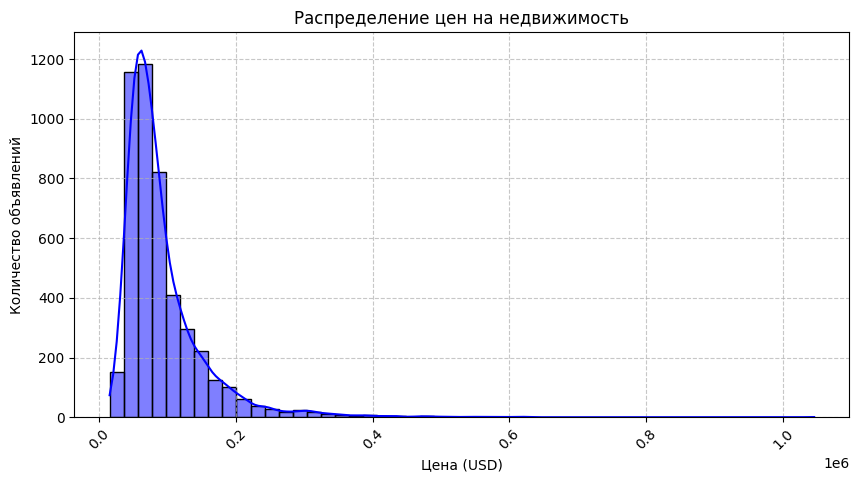

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price_usd'], bins=50, kde=True, color='blue')

# Улучшение визуализации
plt.xlabel("Цена (USD)")
plt.ylabel("Количество объявлений")
plt.title("Распределение цен на недвижимость")
plt.grid(True, linestyle='--', alpha=0.7)  # Добавляем сетку для наглядности

# Явные подписи диапазонов цен
plt.xticks(rotation=45)  # Поворачиваем подписи оси X для читаемости
plt.show()


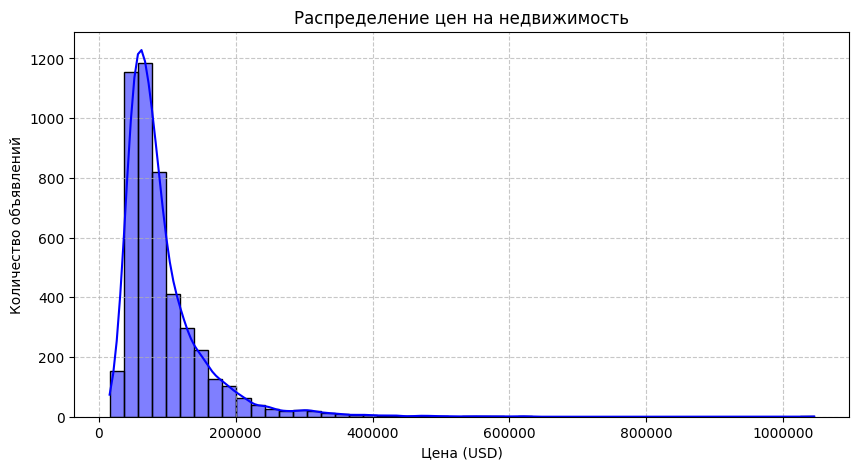

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df['price_usd'], bins=50, kde=True, color='blue', stat="count")
plt.xlabel("Цена (USD)")
plt.ylabel("Количество объявлений")
plt.title("Распределение цен на недвижимость")
plt.grid(True, linestyle='--', alpha=0.7)
plt.ticklabel_format(style='plain', axis='x')  # Отключает научную нотацию
plt.show()


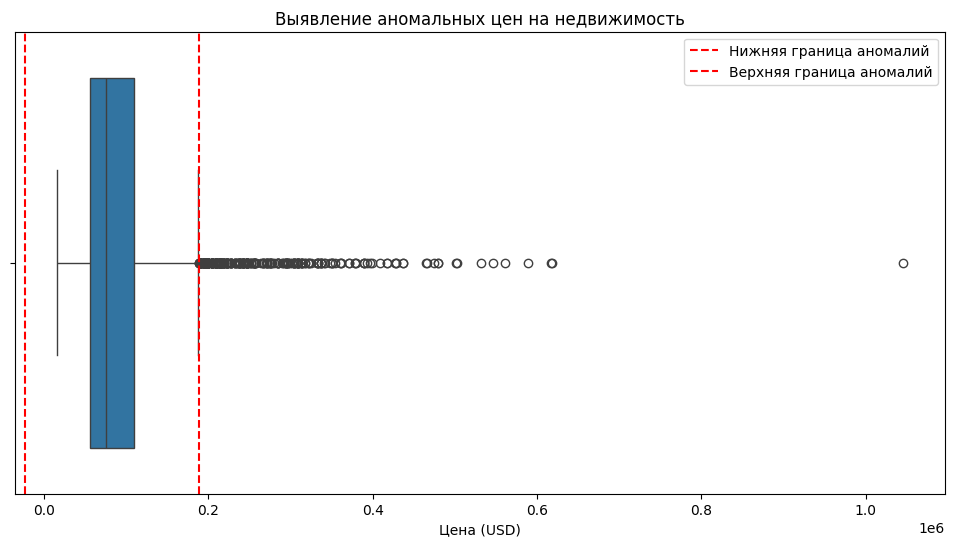

In [12]:
# 11. Выявление аномалий в ценах
Q1 = df['price_usd'].quantile(0.25)
Q3 = df['price_usd'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['price_usd'] < lower_bound) | (df['price_usd'] > upper_bound)]

plt.figure(figsize=(12, 6))
sns.boxplot(x=df['price_usd'])
plt.axvline(lower_bound, color='red', linestyle='dashed', label='Нижняя граница аномалий')
plt.axvline(upper_bound, color='red', linestyle='dashed', label='Верхняя граница аномалий')
plt.xlabel("Цена (USD)")
plt.title("Выявление аномальных цен на недвижимость")
plt.legend()
plt.show()

<ipython-input-13-a027762bbd35>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_addresses.index, y=top_addresses.values, palette='coolwarm')


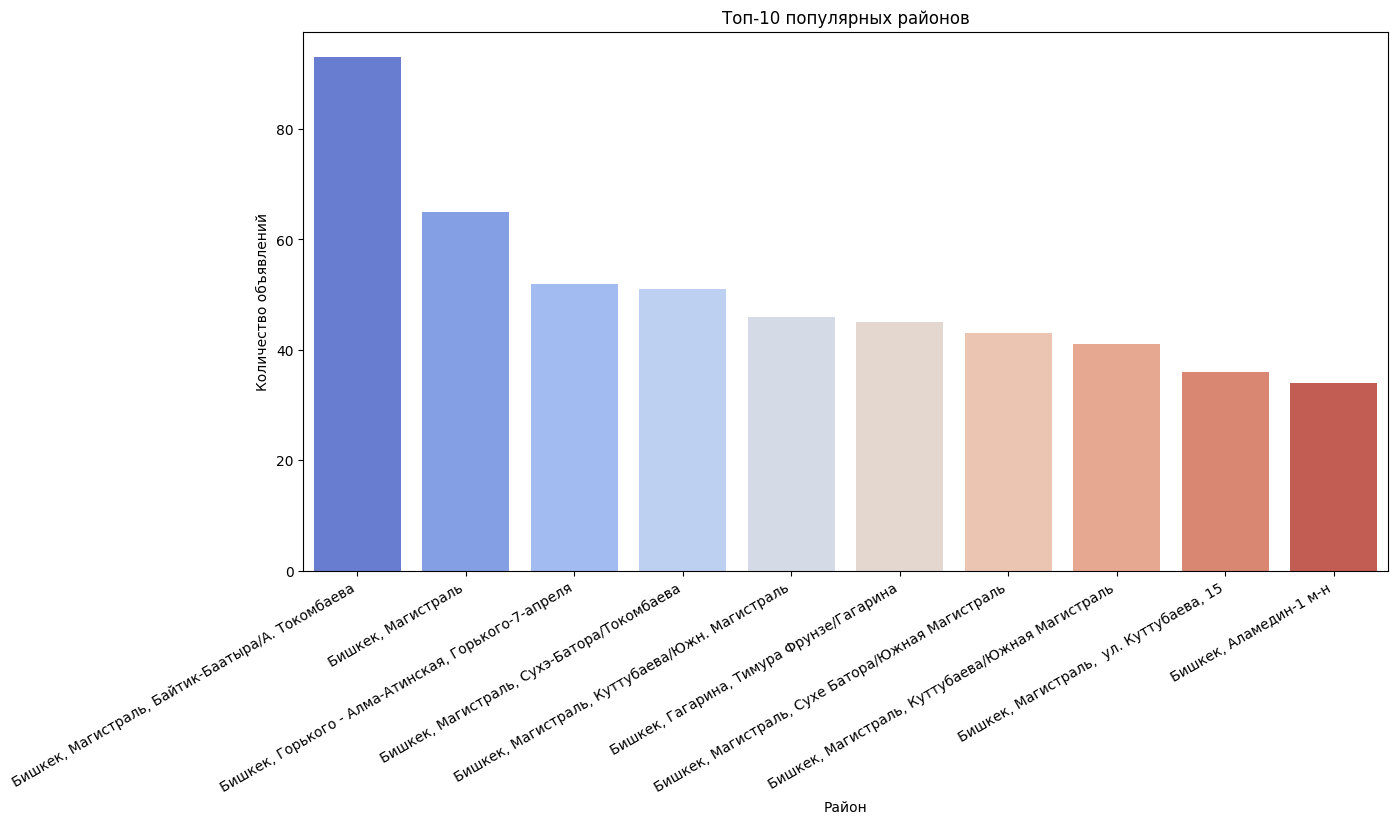

In [13]:
# 4. Барчарт популярных районов
top_addresses = df['address'].value_counts().nlargest(10)
plt.figure(figsize=(14, 7))
sns.barplot(x=top_addresses.index, y=top_addresses.values, palette='coolwarm')
plt.xlabel("Район")
plt.ylabel("Количество объявлений")
plt.title("Топ-10 популярных районов")
plt.xticks(rotation=30, ha='right')  # Немного поворачиваем текст, чтобы лучше читалось
plt.show()


In [ ]:
!pip install geopandas

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Загрузка встроенной карты мира GeoPandas
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

# Создание GeoDataFrame из широты и долготы
df['geometry'] = gpd.points_from_xy(df.longitude, df.latitude)
gdf = gpd.GeoDataFrame(df, geometry='geometry')

# Рисуем карту
fig, ax = plt.subplots(figsize=(10, 6))
world.plot(ax=ax, color='lightgrey', edgecolor='black')
gdf.plot(ax=ax, markersize=5, color='red', alpha=0.5)

plt.xlabel("Долгота")
plt.ylabel("Широта")
plt.title("Расположение объектов недвижимости")
plt.show()


AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

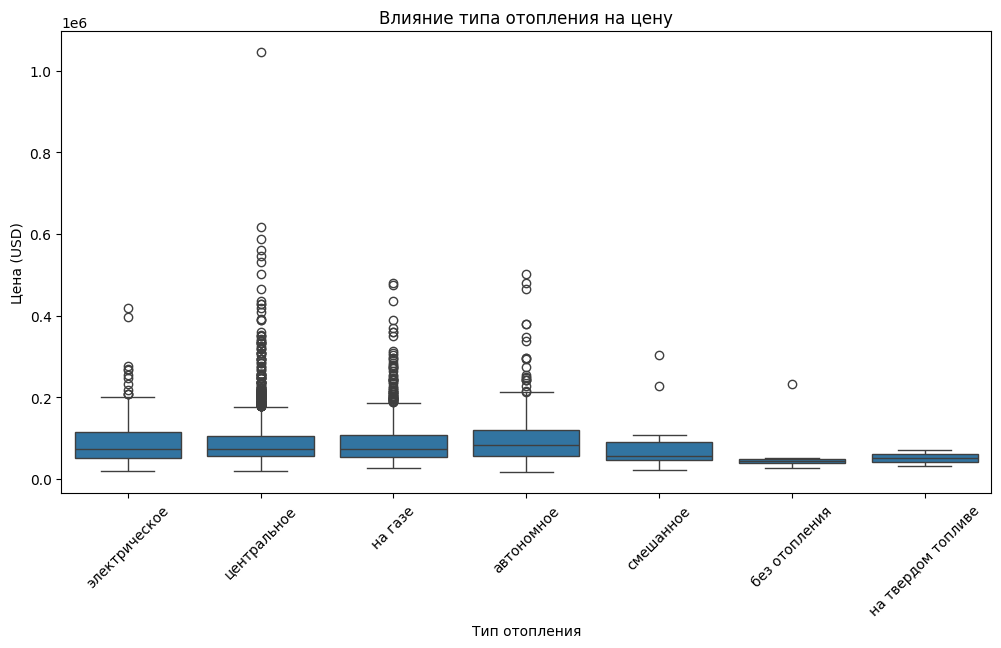

In [16]:
# 7. Влияние типа отопления на цену
df.dropna(subset=['heating', 'price_usd'], inplace=True)
plt.figure(figsize=(12, 6))
sns.boxplot(x='heating', y='price_usd', data=df)
plt.xlabel("Тип отопления")
plt.ylabel("Цена (USD)")
plt.title("Влияние типа отопления на цену")
plt.xticks(rotation=45)
plt.show()


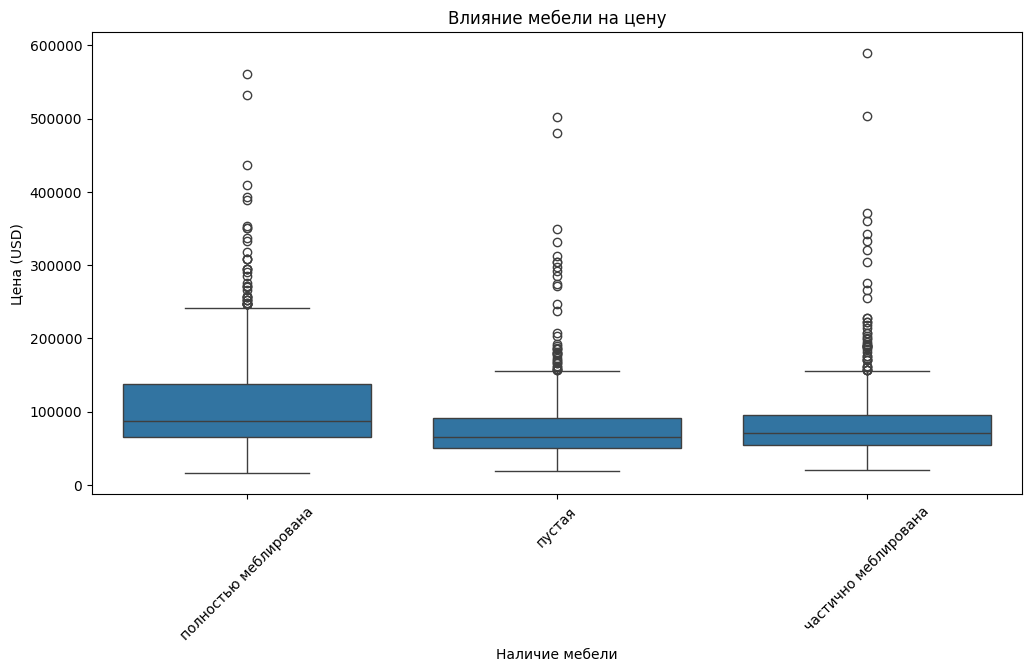

In [17]:
# 8. Влияние наличия мебели на цену
df.dropna(subset=['furniture', 'price_usd'], inplace=True)
plt.figure(figsize=(12, 6))
sns.boxplot(x='furniture', y='price_usd', data=df)
plt.xlabel("Наличие мебели")
plt.ylabel("Цена (USD)")
plt.title("Влияние мебели на цену")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 1. Функция обработки входных данных из JSON
def process_flat_data(flat):
    return {
        "rooms": flat["room_options"],
        "floor": flat["floor"],
        "total_floors": flat["total_floors"],
        "listing_type": flat["listing_type"],
        "series": flat["apartment_series"],
        "condition": flat["conditions"],
        "heating": flat["heating_options"],
        "furniture": flat["furniture_options"],
        "price": flat["price"],
    }

# 2. Загрузка данных


# 3. Заполнение пропусков
df.fillna({
    "furniture": "Неизвестно",
    "series": "Неизвестно",
    "condition": "Неизвестно",
    "heating": "Неизвестно"
}, inplace=True)

# 4. Кодирование категориальных переменных
categorical_cols = ["listing_type", "series", "condition", "heating", "furniture"]
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# 5. Выбор признаков
features = ["rooms", "floor", "total_floors", "listing_type", "series", "condition", "heating", "furniture"]
X = df[features]
y = df["price_usd"]

# 6. Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Обучение модели
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 8. Оценка модели
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae}")

# 9. Функция предсказания цены
def predict_price(flat_json):
    flat_data = process_flat_data(flat_json)
    for col in categorical_cols:
        if flat_data[col] in label_encoders[col].classes_:
            flat_data[col] = label_encoders[col].transform([flat_data[col]])[0]
        else:
            flat_data[col] = -1  # Для неизвестных значений

    input_data = np.array([list(flat_data.values())[:-1]]).reshape(1, -1)
    return model.predict(input_data)[0]

# 10. Тест предсказания
sample_flat = {
    "listing_type": "Продажа",
    "apartment_series": "Индивидуальный проект",
    "heating_options": "Центральное",
    "conditions": "Отличное",
    "furniture_options": "Меблирована",
    "room_options": 3,
    "floor": 5,
    "total_floors": 10,
    "price": 100000  # Фактическая цена, не используется в предсказании
}

predicted_price = predict_price(sample_flat)
print(f"Predicted price: {predicted_price}")


KeyError: 'listing_type'